# Variational Autoencoder with PyTorch 

In [61]:
pip install torch torchvision

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 24.3.1
[notice] To update, run: C:\Users\BOUKA\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


## Imports 

In [62]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load in 

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
# Input data files are available in the "../input/" directory.
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory
import os
for dirname, _, filenames in os.walk('/inputs'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
        
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import nn, optim
from torch.autograd import Variable
from sklearn.decomposition import PCA

import pandas as pd
import numpy as np
from sklearn import preprocessing

# Any results you write to the current directory are saved as output.

In [63]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cpu')

## Get a quick view of the data 

In [64]:
DATA_PATH = r'C:\Users\BOUKA\Downloads\VAE-Code\inputs\hypothyroid.csv'
df = pd.read_csv(DATA_PATH, sep=',')
df.columns

Index(['age', 'sex', 'on thyroxine', 'query on thyroxine',
       'on antithyroid medication', 'sick', 'pregnant', 'thyroid surgery',
       'I131 treatment', 'query hypothyroid', 'query hyperthyroid', 'lithium',
       'goitre', 'tumor', 'hypopituitary', 'psych', 'TSH measured', 'TSH',
       'T3 measured', 'T3', 'TT4 measured', 'TT4', 'T4U measured', 'T4U',
       'FTI measured', 'FTI', 'TBG measured', 'TBG', 'referral source',
       'binaryClass'],
      dtype='object')

## Process datasets

### Hypothyroid dataset

In [65]:
import matplotlib.pyplot as plt
import seaborn as sns

In [66]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3772 entries, 0 to 3771
Data columns (total 30 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   age                        3772 non-null   object
 1   sex                        3772 non-null   object
 2   on thyroxine               3772 non-null   object
 3   query on thyroxine         3772 non-null   object
 4   on antithyroid medication  3772 non-null   object
 5   sick                       3772 non-null   object
 6   pregnant                   3772 non-null   object
 7   thyroid surgery            3772 non-null   object
 8   I131 treatment             3772 non-null   object
 9   query hypothyroid          3772 non-null   object
 10  query hyperthyroid         3772 non-null   object
 11  lithium                    3772 non-null   object
 12  goitre                     3772 non-null   object
 13  tumor                      3772 non-null   object
 14  hypopitu

In [67]:
df['binaryClass'].value_counts()

binaryClass
P    3481
N     291
Name: count, dtype: int64

* Label here is the binary class: containting two classes only P means (Hyperthyroid or hypothroid) and N (negative means normal function)

In [68]:
for col in df.columns:
    print(f"{col} unique vals: {df[col].unique()}, count values {df[col].value_counts()}")

age unique vals: ['41' '23' '46' '70' '18' '59' '80' '66' '68' '84' '67' '71' '28' '65'
 '42' '63' '51' '81' '54' '55' '60' '25' '73' '34' '78' '37' '85' '26'
 '58' '64' '44' '48' '61' '35' '83' '21' '87' '53' '77' '27' '69' '74'
 '38' '76' '45' '36' '22' '43' '72' '82' '31' '39' '49' '62' '57' '1' '50'
 '30' '29' '75' '19' '7' '79' '17' '24' '15' '32' '47' '16' '52' '33' '13'
 '10' '89' '56' '20' '90' '40' '88' '14' '86' '94' '12' '4' '11' '8' '5'
 '455' '2' '91' '6' '?' '93' '92'], count values age
59     95
60     91
70     90
73     81
55     81
       ..
4       1
5       1
455     1
6       1
?       1
Name: count, Length: 94, dtype: int64
sex unique vals: ['F' 'M' '?'], count values sex
F    2480
M    1142
?     150
Name: count, dtype: int64
on thyroxine unique vals: ['f' 't'], count values on thyroxine
f    3308
t     464
Name: count, dtype: int64
query on thyroxine unique vals: ['f' 't'], count values query on thyroxine
f    3722
t      50
Name: count, dtype: int64
on antithyr

In [69]:
df.columns

Index(['age', 'sex', 'on thyroxine', 'query on thyroxine',
       'on antithyroid medication', 'sick', 'pregnant', 'thyroid surgery',
       'I131 treatment', 'query hypothyroid', 'query hyperthyroid', 'lithium',
       'goitre', 'tumor', 'hypopituitary', 'psych', 'TSH measured', 'TSH',
       'T3 measured', 'T3', 'TT4 measured', 'TT4', 'T4U measured', 'T4U',
       'FTI measured', 'FTI', 'TBG measured', 'TBG', 'referral source',
       'binaryClass'],
      dtype='object')

- columns: `age`, `sex`, `TSH`, `T3`, `TT4`, `T4U`, `FTI`, `TBG` have values of `?`. The `?` will be replaced be `nan`
- columns: `TBG measured` and `TBG` have only one value that is `f` and `?`. Those two variables should be deleted as they don't explain any variance.

In [70]:
df.replace('?', np.nan, inplace=True)
for col in df.columns:
    print(f"{col} unique vals: {df[col].unique()}")

age unique vals: ['41' '23' '46' '70' '18' '59' '80' '66' '68' '84' '67' '71' '28' '65'
 '42' '63' '51' '81' '54' '55' '60' '25' '73' '34' '78' '37' '85' '26'
 '58' '64' '44' '48' '61' '35' '83' '21' '87' '53' '77' '27' '69' '74'
 '38' '76' '45' '36' '22' '43' '72' '82' '31' '39' '49' '62' '57' '1' '50'
 '30' '29' '75' '19' '7' '79' '17' '24' '15' '32' '47' '16' '52' '33' '13'
 '10' '89' '56' '20' '90' '40' '88' '14' '86' '94' '12' '4' '11' '8' '5'
 '455' '2' '91' '6' nan '93' '92']
sex unique vals: ['F' 'M' nan]
on thyroxine unique vals: ['f' 't']
query on thyroxine unique vals: ['f' 't']
on antithyroid medication unique vals: ['f' 't']
sick unique vals: ['f' 't']
pregnant unique vals: ['f' 't']
thyroid surgery unique vals: ['f' 't']
I131 treatment unique vals: ['f' 't']
query hypothyroid unique vals: ['f' 't']
query hyperthyroid unique vals: ['f' 't']
lithium unique vals: ['f' 't']
goitre unique vals: ['f' 't']
tumor unique vals: ['f' 't']
hypopituitary unique vals: ['f' 't']
psych u

In [71]:
df.drop(['TBG', 'TBG measured'], axis=1, inplace=True)
df.shape

(3772, 28)

#### Null Values

<Axes: >

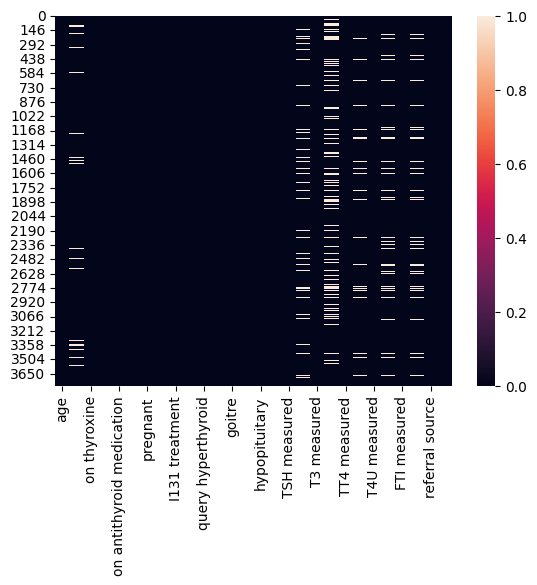

In [72]:
sns.heatmap(df.isnull())

In [73]:
df.isnull().sum()

age                            1
sex                          150
on thyroxine                   0
query on thyroxine             0
on antithyroid medication      0
sick                           0
pregnant                       0
thyroid surgery                0
I131 treatment                 0
query hypothyroid              0
query hyperthyroid             0
lithium                        0
goitre                         0
tumor                          0
hypopituitary                  0
psych                          0
TSH measured                   0
TSH                          369
T3 measured                    0
T3                           769
TT4 measured                   0
TT4                          231
T4U measured                   0
T4U                          387
FTI measured                   0
FTI                          385
referral source                0
binaryClass                    0
dtype: int64

In [74]:
# imputation of missing values using the median for continuous numerical variables and mode for discrete variables

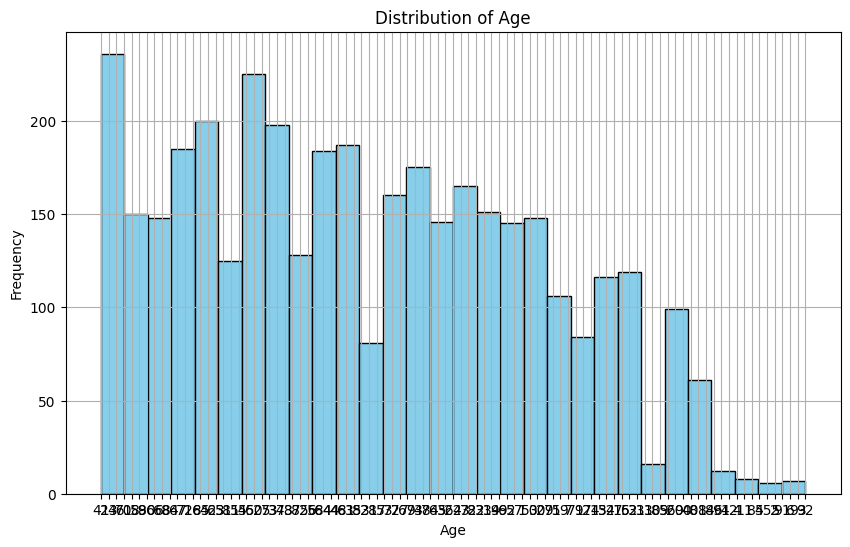

In [75]:
plt.figure(figsize=(10, 6))
plt.hist(df['age'].dropna(), bins=30, color='skyblue', edgecolor='black')  # Dropping NA values for visualization
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

In [76]:
cont_col = ['age', 'TSH', "T3", "TT4", "T4U", "FTI"]
for col in cont_col:
    med = df[col].median()
    df[col].fillna(med, inplace=True)
df.isnull().sum()

age                            0
sex                          150
on thyroxine                   0
query on thyroxine             0
on antithyroid medication      0
sick                           0
pregnant                       0
thyroid surgery                0
I131 treatment                 0
query hypothyroid              0
query hyperthyroid             0
lithium                        0
goitre                         0
tumor                          0
hypopituitary                  0
psych                          0
TSH measured                   0
TSH                            0
T3 measured                    0
T3                             0
TT4 measured                   0
TT4                            0
T4U measured                   0
T4U                            0
FTI measured                   0
FTI                            0
referral source                0
binaryClass                    0
dtype: int64

In [77]:
# imputing the missing values in the `sex` variables, where the mode category is used here
mode_sex = df['sex'].mode()[0]
df['sex'].fillna(mode_sex, inplace=True)


In [78]:
df.isnull().sum()

age                          0
sex                          0
on thyroxine                 0
query on thyroxine           0
on antithyroid medication    0
sick                         0
pregnant                     0
thyroid surgery              0
I131 treatment               0
query hypothyroid            0
query hyperthyroid           0
lithium                      0
goitre                       0
tumor                        0
hypopituitary                0
psych                        0
TSH measured                 0
TSH                          0
T3 measured                  0
T3                           0
TT4 measured                 0
TT4                          0
T4U measured                 0
T4U                          0
FTI measured                 0
FTI                          0
referral source              0
binaryClass                  0
dtype: int64

#### Cleansing the data: removing outliers

In [79]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3772 entries, 0 to 3771
Data columns (total 28 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   age                        3772 non-null   object
 1   sex                        3772 non-null   object
 2   on thyroxine               3772 non-null   object
 3   query on thyroxine         3772 non-null   object
 4   on antithyroid medication  3772 non-null   object
 5   sick                       3772 non-null   object
 6   pregnant                   3772 non-null   object
 7   thyroid surgery            3772 non-null   object
 8   I131 treatment             3772 non-null   object
 9   query hypothyroid          3772 non-null   object
 10  query hyperthyroid         3772 non-null   object
 11  lithium                    3772 non-null   object
 12  goitre                     3772 non-null   object
 13  tumor                      3772 non-null   object
 14  hypopitu

### Visualizations

In [80]:
for col in df.columns:
    print(f"{col} unique vals: {df[col].unique()}, count values {df[col].value_counts()}")

age unique vals: ['41' '23' '46' '70' '18' '59' '80' '66' '68' '84' '67' '71' '28' '65'
 '42' '63' '51' '81' '54' '55' '60' '25' '73' '34' '78' '37' '85' '26'
 '58' '64' '44' '48' '61' '35' '83' '21' '87' '53' '77' '27' '69' '74'
 '38' '76' '45' '36' '22' '43' '72' '82' '31' '39' '49' '62' '57' '1' '50'
 '30' '29' '75' '19' '7' '79' '17' '24' '15' '32' '47' '16' '52' '33' '13'
 '10' '89' '56' '20' '90' '40' '88' '14' '86' '94' '12' '4' '11' '8' '5'
 '455' '2' '91' '6' 54.0 '93' '92'], count values age
59      95
60      91
70      90
73      81
55      81
        ..
4        1
5        1
455      1
6        1
54.0     1
Name: count, Length: 94, dtype: int64
sex unique vals: ['F' 'M'], count values sex
F    2630
M    1142
Name: count, dtype: int64
on thyroxine unique vals: ['f' 't'], count values on thyroxine
f    3308
t     464
Name: count, dtype: int64
query on thyroxine unique vals: ['f' 't'], count values query on thyroxine
f    3722
t      50
Name: count, dtype: int64
on antithyroi

In [81]:
# Convert binary categorical variables to 0 and 1
binary_columns = ['on thyroxine', 'query on thyroxine', 'on antithyroid medication', 'sick', 'pregnant',
                  'thyroid surgery', 'I131 treatment', 'query hypothyroid', 'query hyperthyroid', 
                  'lithium', 'goitre', 'tumor', 'hypopituitary', 'psych', 'TSH measured', 'T3 measured',
                  'TT4 measured', 'T4U measured', 'FTI measured']
df[binary_columns] = df[binary_columns].apply(lambda x: (x == 't').astype(int))

# Convert hormone levels to float
hormone_levels = ['TSH', 'T3', 'TT4', 'T4U', 'FTI']
df[hormone_levels] = df[hormone_levels].apply(pd.to_numeric, errors='coerce')

# Convert age to float first to handle any non-integer values, then convert to int, handling errors and outliers
df['age'] = pd.to_numeric(df['age'], errors='coerce')  # Converts to numeric, coercing errors to NaN
df['age'] = df['age'].astype(int)

In [82]:
# Print the types and head to check
print(df.dtypes)

age                            int32
sex                           object
on thyroxine                   int32
query on thyroxine             int32
on antithyroid medication      int32
sick                           int32
pregnant                       int32
thyroid surgery                int32
I131 treatment                 int32
query hypothyroid              int32
query hyperthyroid             int32
lithium                        int32
goitre                         int32
tumor                          int32
hypopituitary                  int32
psych                          int32
TSH measured                   int32
TSH                          float64
T3 measured                    int32
T3                           float64
TT4 measured                   int32
TT4                          float64
T4U measured                   int32
T4U                          float64
FTI measured                   int32
FTI                          float64
referral source               object
b

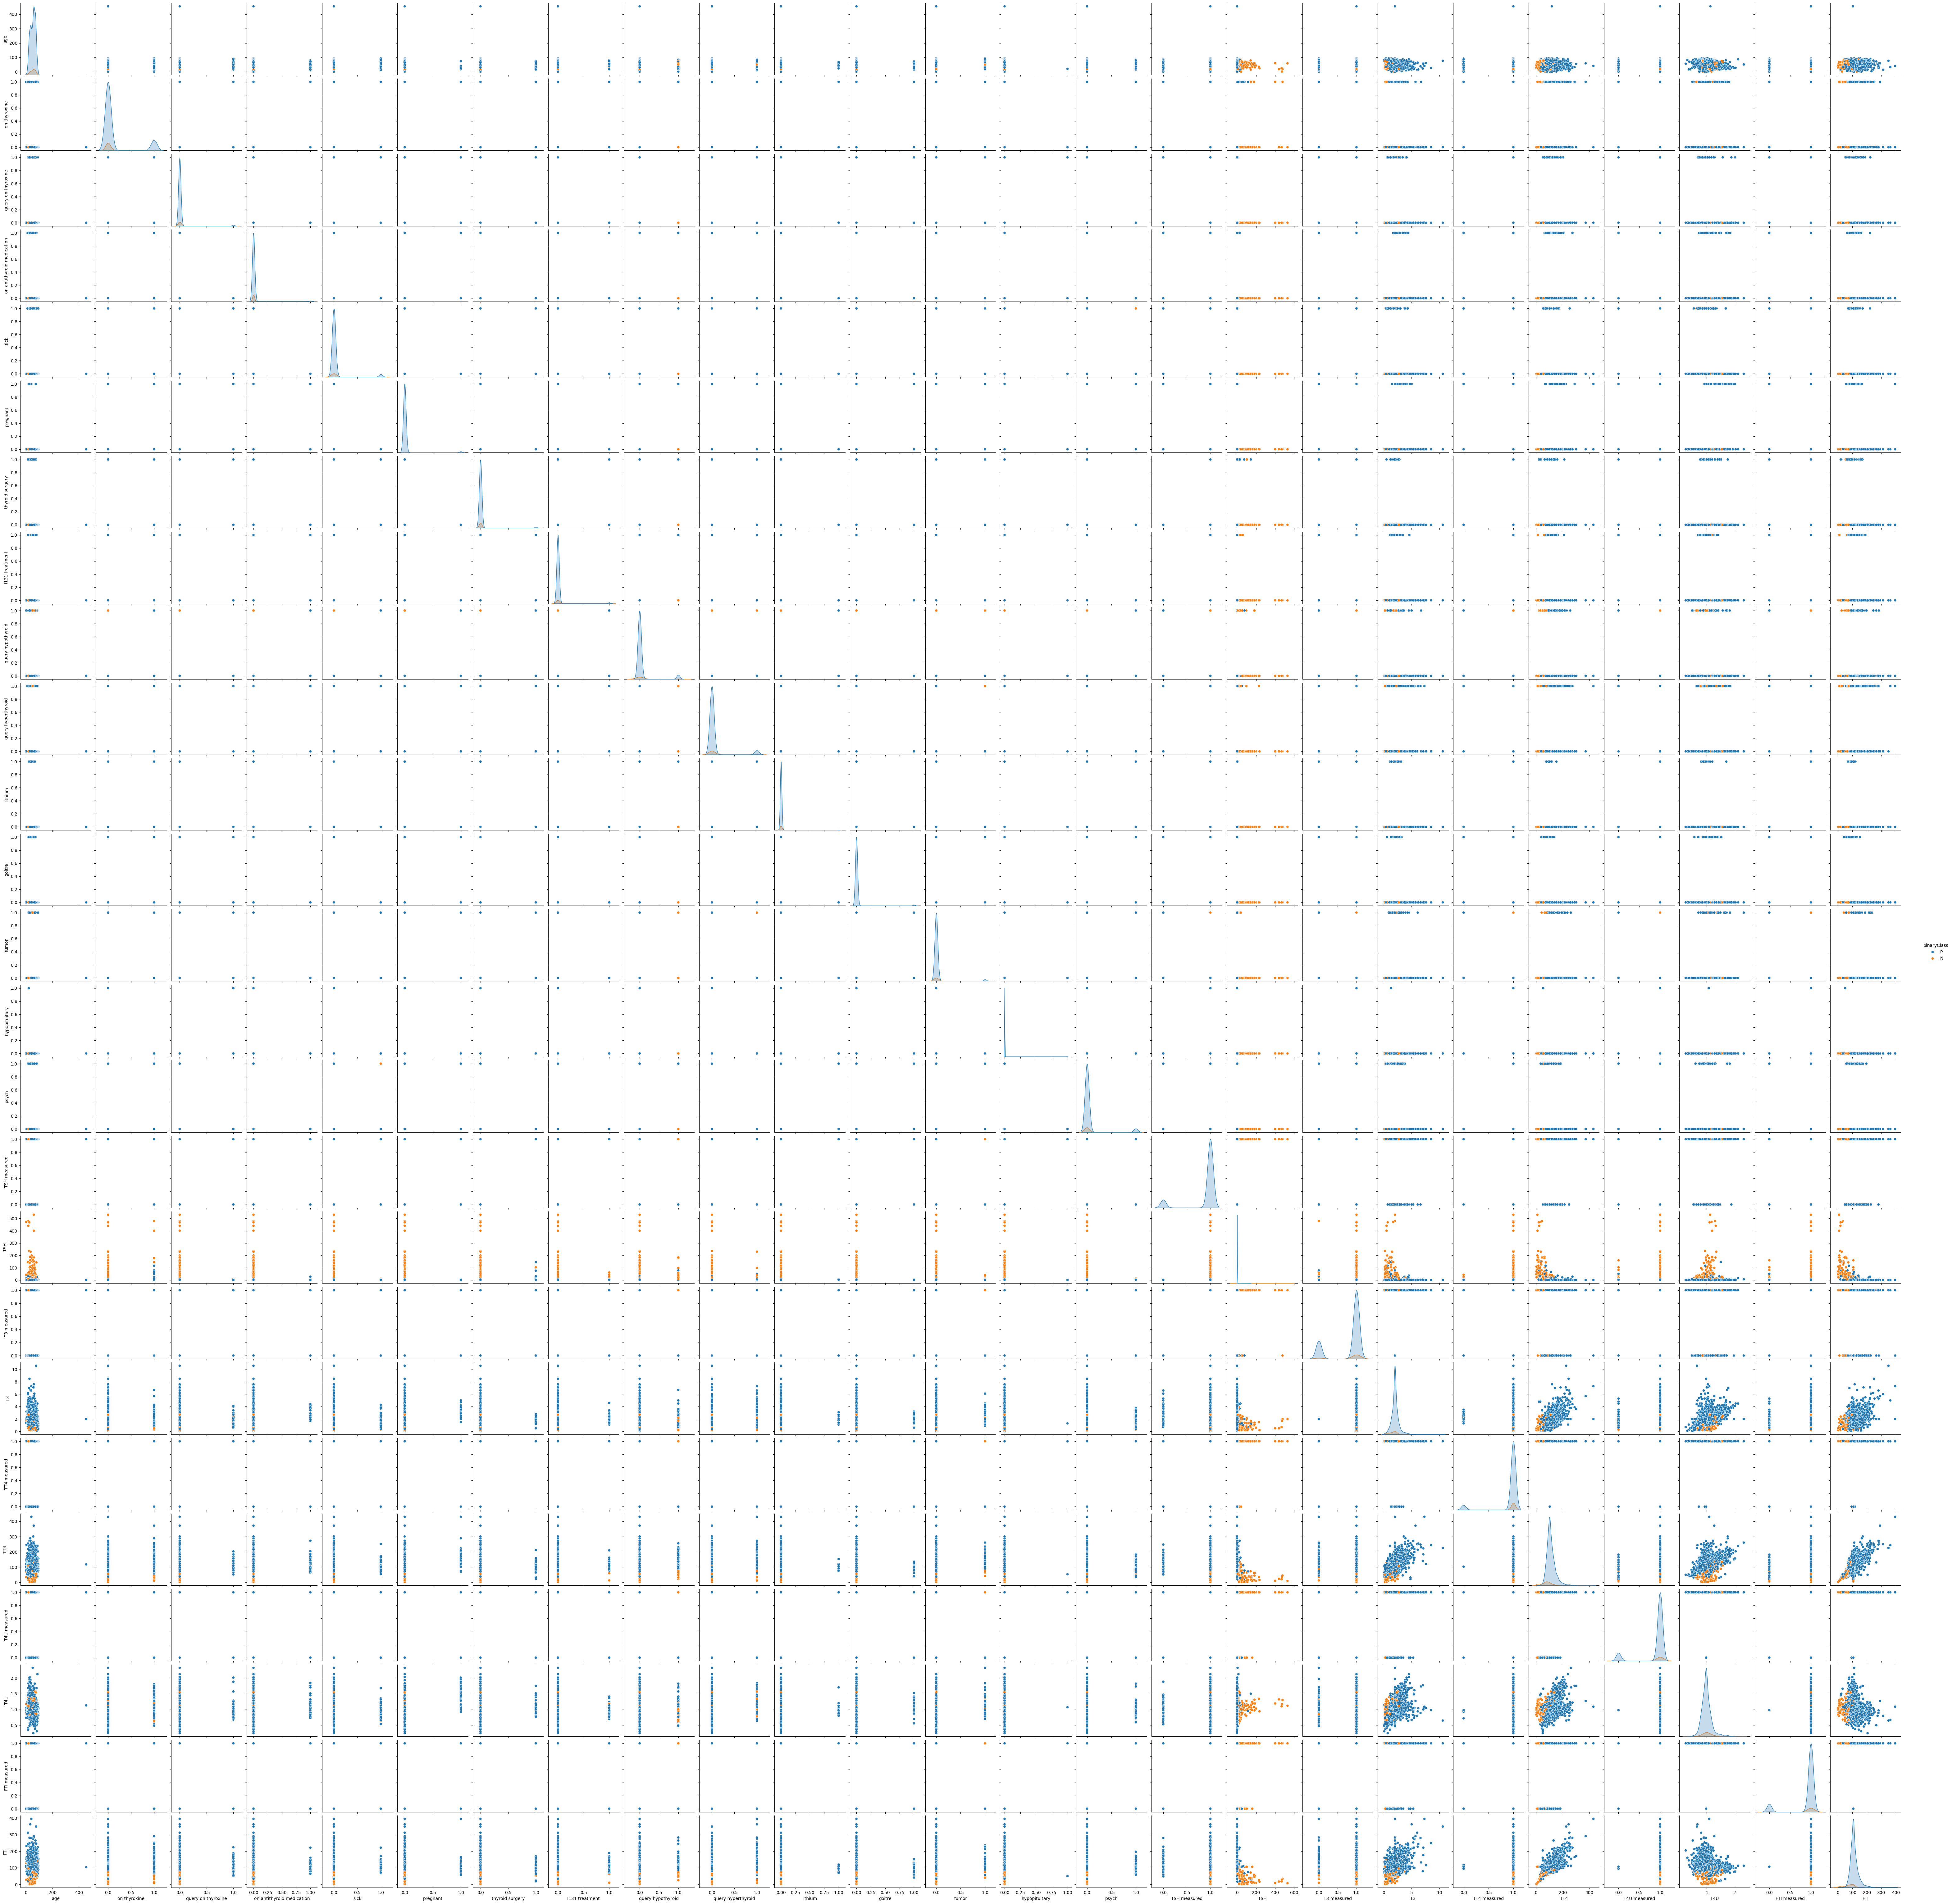

In [83]:
sns.pairplot(data=df, hue='binaryClass')

#### Spearman Rank Correlation

In [84]:
print(df['referral source'].unique())
print(df['sex'].unique())

['SVHC' 'other' 'SVI' 'STMW' 'SVHD']
['F' 'M']


In [85]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
df['sex_encoded'] = label_encoder.fit_transform(df['sex'])
print(df[['sex', 'sex_encoded']].head())

  sex  sex_encoded
0   F            0
1   F            0
2   M            1
3   F            0
4   F            0


In [86]:
# Apply one-hot encoding to 'referral source'
df_one_hot = pd.get_dummies(df['referral source'], prefix='referral')
df_one_hot.drop('referral_other', axis=1, inplace=True)

In [87]:
df = pd.concat([df, df_one_hot], axis=1)
df.drop(['sex','referral source'], axis=1, inplace=True)

In [88]:
df_one_hot.columns

Index(['referral_STMW', 'referral_SVHC', 'referral_SVHD', 'referral_SVI'], dtype='object')

In [89]:
bin_cols = ['referral_STMW', 'referral_SVHC', 'referral_SVHD', 'referral_SVI']
df[bin_cols] = df[bin_cols].apply(lambda x: (x == True).astype(int))

In [90]:
df[bin_cols].head()

,referral_STMW,referral_SVHC,referral_SVHD,referral_SVI
0,0,1,0,0
1,0,0,0,0
2,0,0,0,0
3,0,0,0,0
4,0,0,0,1


<Axes: >

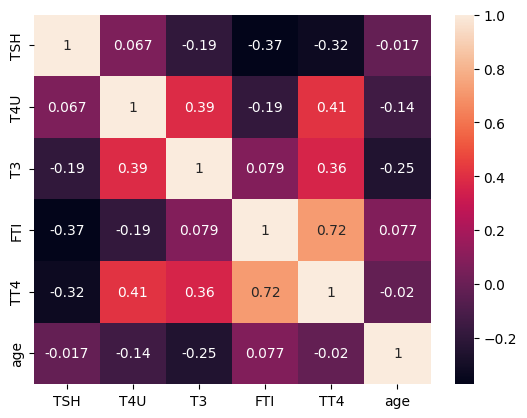

In [91]:
num_col = list(set(['age'] + hormone_levels))
corr = df[num_col].corr(method="spearman")
sns.heatmap(corr,annot=True)

* We drop outlier values using **IQR(Interquartile Range Method)**

In [92]:
mapping_dict = {'P':1, "N":0}
df['binaryClass'] = df['binaryClass'].map(mapping_dict)

print(df['binaryClass'].value_counts())

binaryClass
1    3481
0     291
Name: count, dtype: int64


In [94]:
df.rename(columns={'binaryClass':"Outcome"}, inplace=True)
df.columns

Index(['age', 'on thyroxine', 'query on thyroxine',
       'on antithyroid medication', 'sick', 'pregnant', 'thyroid surgery',
       'I131 treatment', 'query hypothyroid', 'query hyperthyroid', 'lithium',
       'goitre', 'tumor', 'hypopituitary', 'psych', 'TSH measured', 'TSH',
       'T3 measured', 'T3', 'TT4 measured', 'TT4', 'T4U measured', 'T4U',
       'FTI measured', 'FTI', 'Outcome', 'sex_encoded', 'referral_STMW',
       'referral_SVHC', 'referral_SVHD', 'referral_SVI'],
      dtype='object')

In [96]:
new_order = ['age', 'on thyroxine', 'query on thyroxine',
       'on antithyroid medication', 'sick', 'pregnant', 'thyroid surgery',
       'I131 treatment', 'query hypothyroid', 'query hyperthyroid', 'lithium',
       'goitre', 'tumor', 'hypopituitary', 'psych', 'TSH measured', 'TSH',
       'T3 measured', 'T3', 'TT4 measured', 'TT4', 'T4U measured', 'T4U',
       'FTI measured', 'FTI', 'sex_encoded', 'referral_STMW',
       'referral_SVHC', 'referral_SVHD', 'referral_SVI',  'Outcome']
assert set(new_order) == set(df.columns), "New order must include all cols"

In [97]:
df= df[new_order]

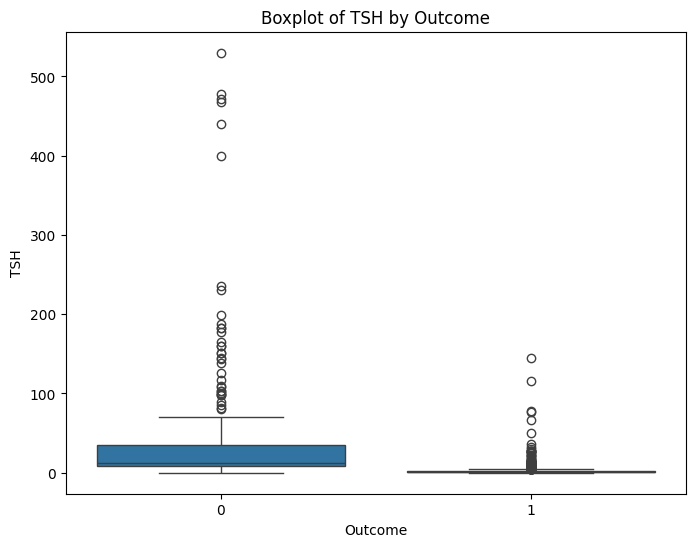

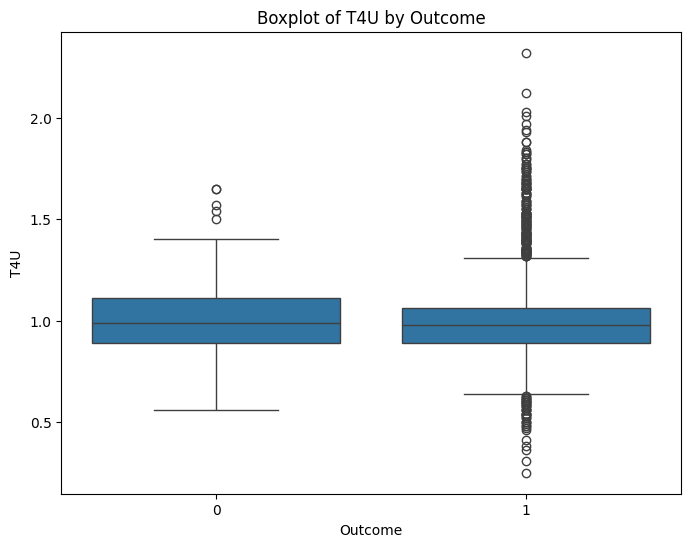

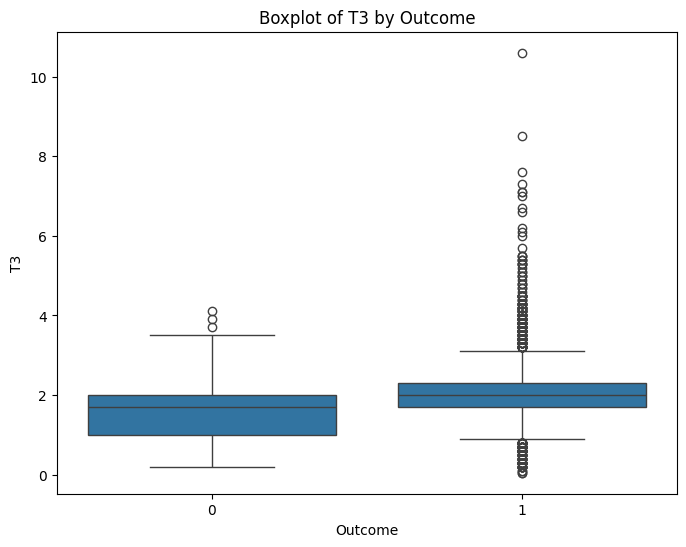

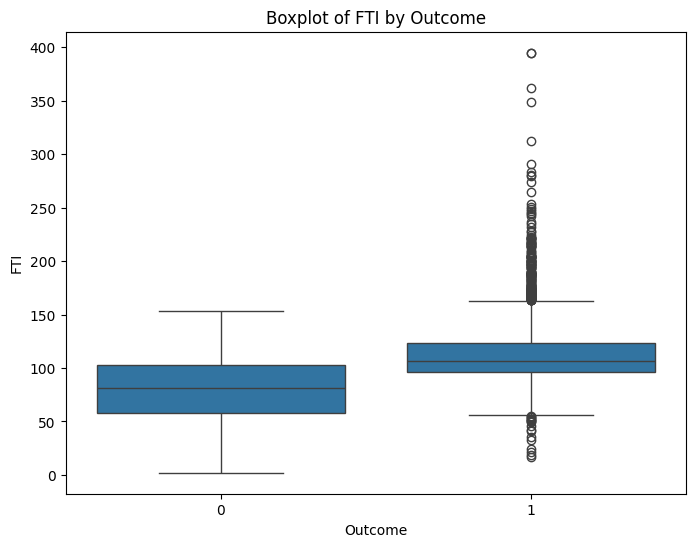

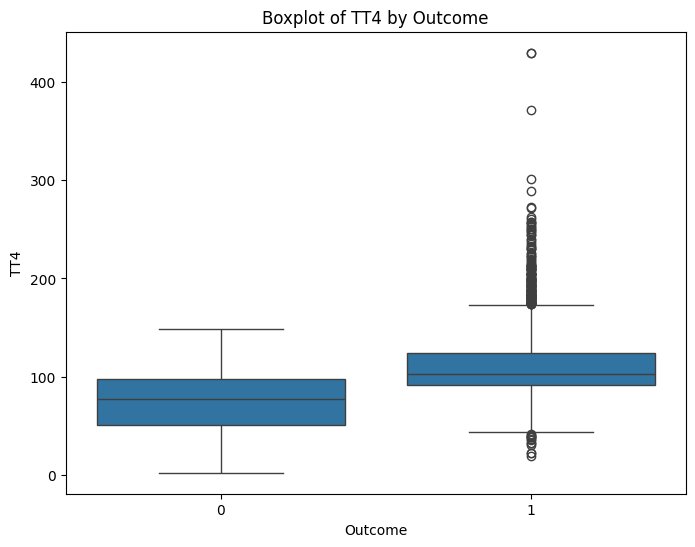

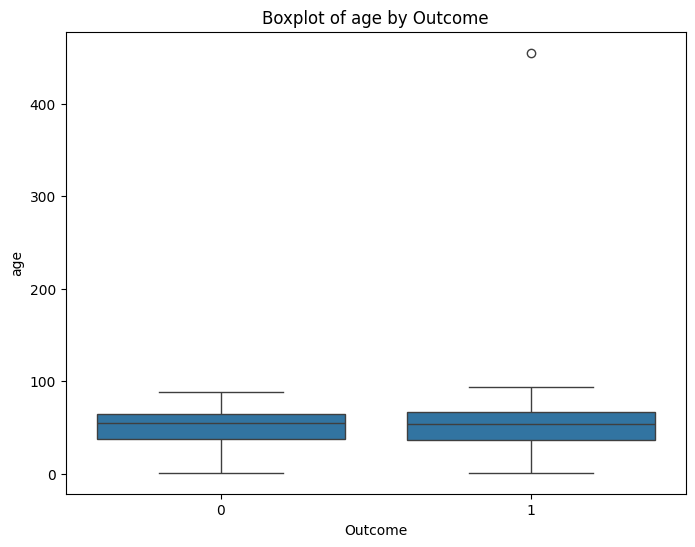

In [98]:
for col in num_col:
        plt.figure(figsize=(8, 6))
        sns.boxplot(data=df, x="Outcome", y=col)
        plt.title(f'Boxplot of {col} by Outcome')
        plt.show()

In [99]:
def removeOutlier(col):
    sorted(col)
    quant1, quant2 = col.quantile([0.25, 0.75])
    IQR = quant2 - quant1
    lowerRange = quant1 - (1.5 * IQR)
    upperRange = quant2 + (1.5 * IQR)
    return lowerRange, upperRange

In [101]:
df[num_col].describe()

,TSH,T4U,T3,FTI,TT4,age
count,3772.000000,3772.000000,3772.000000,3772.000000,3772.000000,3772.000000
mean,4.726104,0.993461,2.010748,110.115509,107.993584,51.736479
std,23.316598,0.185212,0.738282,31.372681,34.520088,20.082329
min,0.005000,0.250000,0.050000,2.000000,2.000000,1.000000
25%,0.600000,0.890000,1.700000,94.000000,89.000000,36.000000
50%,1.400000,0.980000,2.000000,107.000000,103.000000,54.000000
75%,2.425000,1.070000,2.200000,121.250000,123.000000,67.000000
max,530.000000,2.320000,10.600000,395.000000,430.000000,455.000000


In [102]:
for col in num_col:
    lowScore, highScore = removeOutlier(df[col])
    print(f"Column: {col}, Lower Bound: {lowScore}, Upper Bound: {highScore}")
    df[col] = np.where(df[col]>highScore, highScore, df[col])
    df[col] = np.where(df[col]<lowScore, lowScore, df[col])

Column: TSH, Lower Bound: -2.1374999999999997, Upper Bound: 5.1625
Column: T4U, Lower Bound: 0.6199999999999999, Upper Bound: 1.34
Column: T3, Lower Bound: 0.9499999999999996, Upper Bound: 2.9500000000000006
Column: FTI, Lower Bound: 53.125, Upper Bound: 162.125
Column: TT4, Lower Bound: 38.0, Upper Bound: 174.0
Column: age, Lower Bound: -10.5, Upper Bound: 113.5


In [103]:
df[num_col].describe()

,TSH,T4U,T3,FTI,TT4,age
count,3772.000000,3772.000000,3772.000000,3772.000000,3772.000000,3772.000000
mean,1.806319,0.984948,1.970610,108.919042,106.907741,51.645944
std,1.593658,0.152545,0.507725,24.269787,29.118836,19.004713
min,0.005000,0.620000,0.950000,53.125000,38.000000,1.000000
25%,0.600000,0.890000,1.700000,94.000000,89.000000,36.000000
50%,1.400000,0.980000,2.000000,107.000000,103.000000,54.000000
75%,2.425000,1.070000,2.200000,121.250000,123.000000,67.000000
max,5.162500,1.340000,2.950000,162.125000,174.000000,113.500000


* **Check if the outliers are handled**

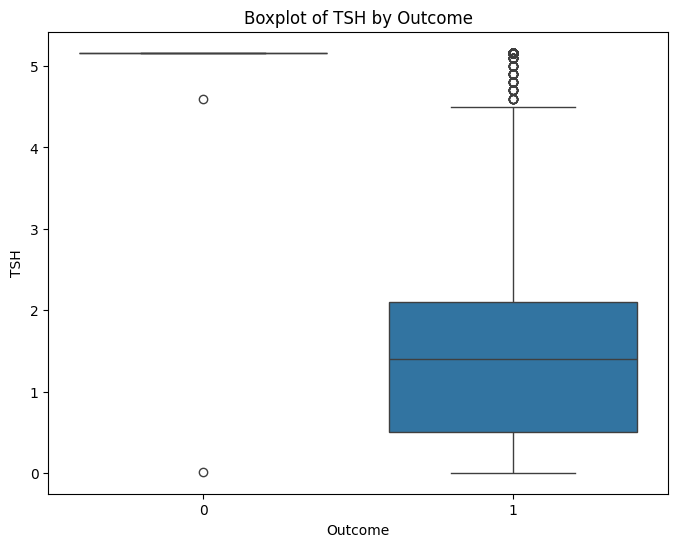

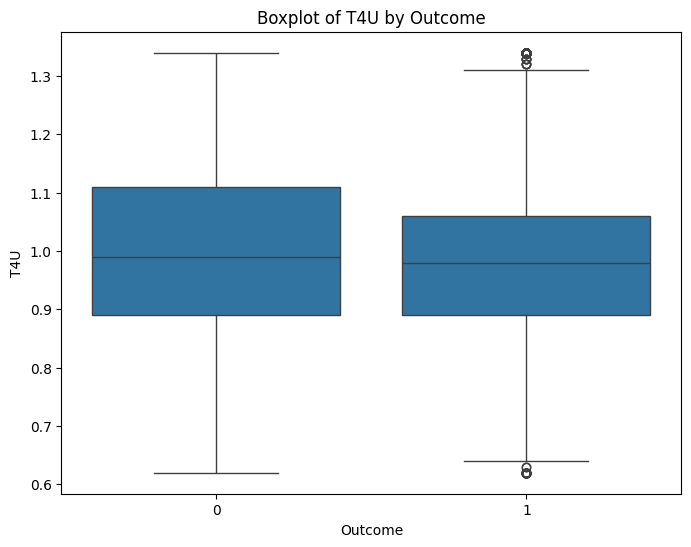

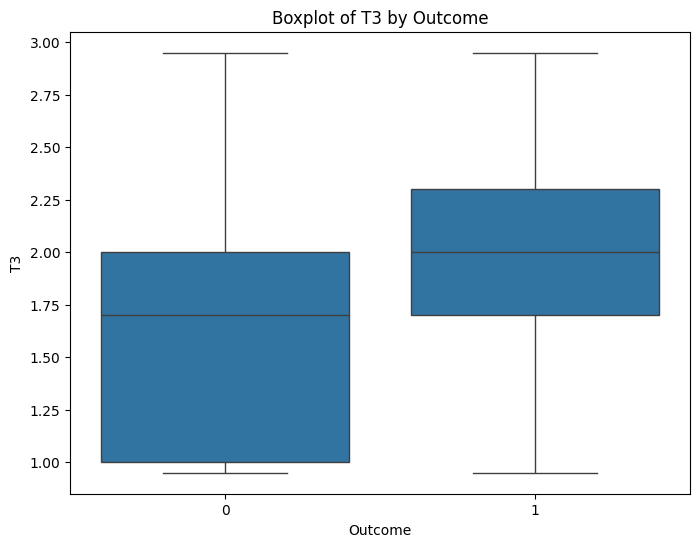

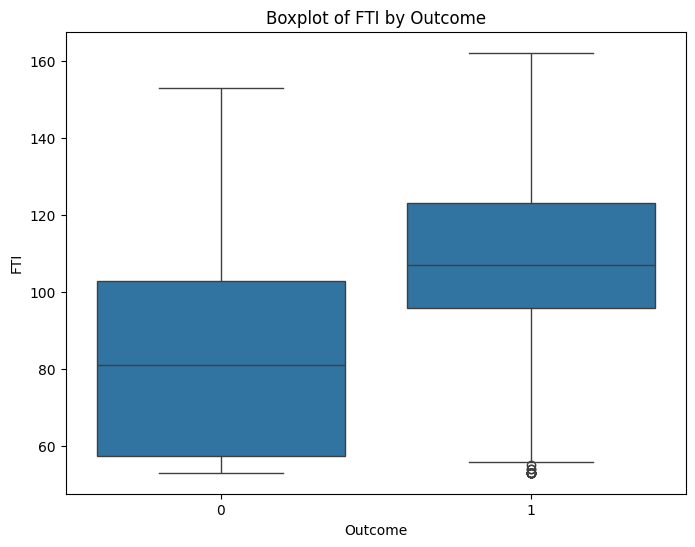

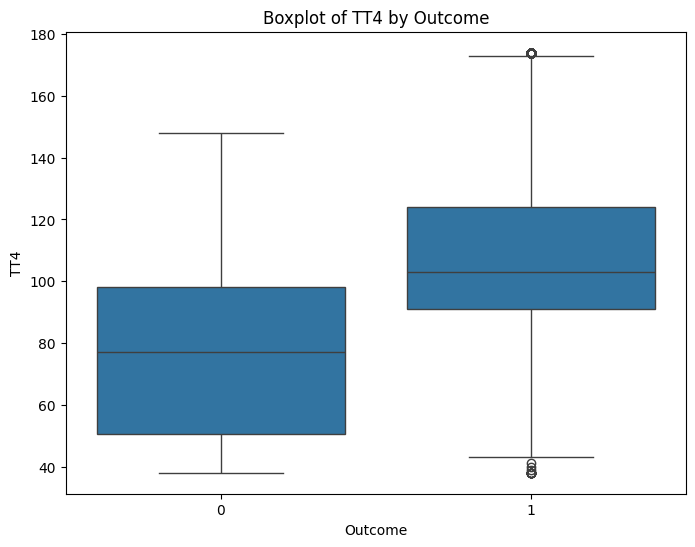

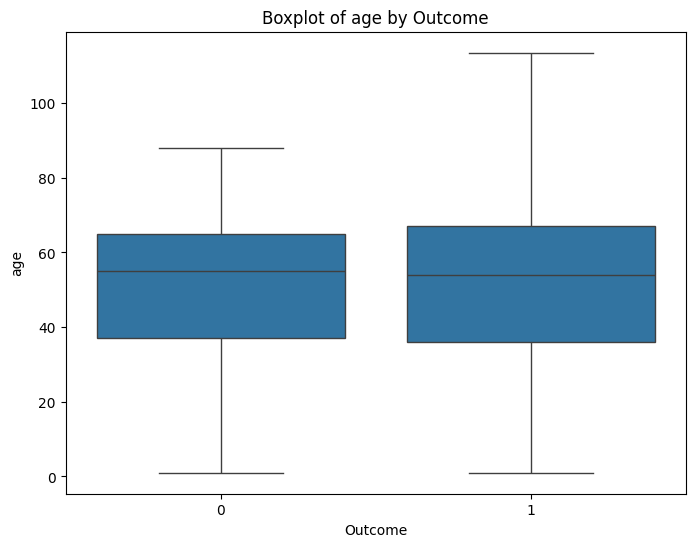

In [104]:
cols = [col for col in df.columns if col!="Outcome"]
for col in num_col:
        plt.figure(figsize=(8, 6))
        sns.boxplot(data=df, x="Outcome", y=col)
        plt.title(f'Boxplot of {col} by Outcome')
        plt.show()

### save the preprocessed dataset "Hypothyroid_processed.csv"

In [105]:
df.head()

,age,on thyroxine,query on thyroxine,on antithyroid medication,sick,pregnant,thyroid surgery,I131 treatment,query hypothyroid,query hyperthyroid,...,T4U measured,T4U,FTI measured,FTI,sex_encoded,referral_STMW,referral_SVHC,referral_SVHD,referral_SVI,Outcome
0,41.0,0,0,0,0,0,0,0,0,0,...,1,1.14,1,109.0,0,0,1,0,0,1
1,23.0,0,0,0,0,0,0,0,0,0,...,0,0.98,0,107.0,0,0,0,0,0,1
2,46.0,0,0,0,0,0,0,0,0,0,...,1,0.91,1,120.0,1,0,0,0,0,1
3,70.0,1,0,0,0,0,0,0,0,0,...,0,0.98,0,107.0,0,0,0,0,0,1
4,70.0,0,0,0,0,0,0,0,0,0,...,1,0.87,1,70.0,0,0,0,0,1,1


In [106]:
df.to_csv(path_or_buf="Hypothyroid_processed.csv")

### Preprocessing the dataset "Dermatology"

## Define Functions 

In [920]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

def load_data(path_processed, test_size = test_size, random_state=random_state):
    # Read the data from a CSV file
    df = pd.read_csv(path_processed, sep=',')
    #df.drop('Pregnancies', axis=1, inplace=True)
    
    # Replace NaN values with a placeholder (e.g., -99)
    #df = df.dropna()
    
    # Separate features and labels
    df_base = df.iloc[:, :-1]  # Features
    df_labels = df.iloc[:, -1].values  # Labels
    # Split data into train and test sets using stratified random sampling
    X_train, X_test, y_train, y_test = train_test_split(
        df_base.values,
        df_labels,
        test_size=test_size,
        stratify=df_labels,
        random_state=random_state
    )
    
    
    # Fit the StandardScaler on training data and transform both train and test sets
    standardizer = StandardScaler()
    X_train = standardizer.fit_transform(X_train)  # Fit and transform training data
    X_test = standardizer.transform(X_test)       # Transform test data only
    
    # Identify majority and minority classes in the training set
    label_counts = pd.Series(y_train).value_counts()
    print(label_counts)
    minority_label = label_counts.idxmin()
    majority_label = label_counts.idxmax()

    # Calculate imbalance ratio
    minority_count = label_counts[minority_label]
    majority_count = label_counts[majority_label]
    imbalance_ratio = minority_count / majority_count
    
    # Separate the training data into majority and minority classes
    minority_data = X_train[y_train == minority_label]
    majority_data = X_train[y_train == majority_label]
    
    # Print imbalance ratio
    print(f"Imbalance Ratio (IR): {imbalance_ratio:.2f} (Majority: {majority_count}, Minority: {minority_count})")
    print(f"type of minority data: {type(minority_data)}")
    # Return train/test sets, scaler, and separated majority/minority data
    return X_train, y_train, X_test, y_test, standardizer, majority_data, minority_data, imbalance_ratio

def numpyToTensor(x):
    x_train = torch.from_numpy(x).to(device)
    return x_train

## Build Data Loader 

In [923]:
from torch.utils.data import Dataset, DataLoader
class DataBuilderMin(Dataset):
    def __init__(self, path):
        _,_,_,_, self.standardizer, _, self.x, _ = load_data(DATA_PATH)
        self.x = numpyToTensor(self.x)
        self.len=self.x.shape[0]
    def __getitem__(self,index):      
        return self.x[index]
    def __len__(self):
        return self.len

class DataBuilderMaj(Dataset):
    def __init__(self, path):
        _,_,_,_, self.standardizer, self.x, _, _ = load_data(DATA_PATH)
        self.x = numpyToTensor(self.x)
        self.len=self.x.shape[0]
    def __getitem__(self,index):      
        return self.x[index]
    def __len__(self):
        return self.len

## Build Model and train it

Usually VAE are used for Image processing and creating (like GANS Models). This is explained here: https://towardsdatascience.com/understanding-variational-autoencoders-vaes-f70510919f73
However, we can adapt this approach to use it on tabular data. This way the Autoencoder helps us reducing dimensionality of data and also reduce noise.

In [927]:
# Initialize the H=H, H2=H2, latent_dim=latent_dim

class Autoencoder(nn.Module):
    def __init__(self,D_in,H=60,H2=30,latent_dim=6):
        
        #Encoder
        super(Autoencoder,self).__init__()
        self.linear1=nn.Linear(D_in,H)
        self.lin_bn1 = nn.BatchNorm1d(num_features=H)
        self.linear2=nn.Linear(H,H2)
        self.lin_bn2 = nn.BatchNorm1d(num_features=H2)
        self.linear3=nn.Linear(H2,H2)
        self.lin_bn3 = nn.BatchNorm1d(num_features=H2)
        
#         # Latent vectors mu and sigma
        self.fc1 = nn.Linear(H2, latent_dim)
        self.bn1 = nn.BatchNorm1d(num_features=latent_dim)
        self.fc21 = nn.Linear(latent_dim, latent_dim)
        self.fc22 = nn.Linear(latent_dim, latent_dim)

#         # Sampling vector
        self.fc3 = nn.Linear(latent_dim, latent_dim)
        self.fc_bn3 = nn.BatchNorm1d(latent_dim)
        self.fc4 = nn.Linear(latent_dim, H2)
        self.fc_bn4 = nn.BatchNorm1d(H2)
        
#         # Decoder
        self.linear4=nn.Linear(H2,H2)
        self.lin_bn4 = nn.BatchNorm1d(num_features=H2)
        self.linear5=nn.Linear(H2,H)
        self.lin_bn5 = nn.BatchNorm1d(num_features=H)
        self.linear6=nn.Linear(H,D_in)
        self.lin_bn6 = nn.BatchNorm1d(num_features=D_in)
        
        self.relu = nn.ReLU()
        
    def encode(self, x):
        lin1 = self.relu(self.lin_bn1(self.linear1(x)))
        lin2 = self.relu(self.lin_bn2(self.linear2(lin1)))
        lin3 = self.relu(self.lin_bn3(self.linear3(lin2)))

        fc1 = F.relu(self.bn1(self.fc1(lin3)))

        r1 = self.fc21(fc1)
        r2 = self.fc22(fc1)
        
        return r1, r2
    
    def reparameterize(self, mu, logvar):
        if self.training:
            std = logvar.mul(0.5).exp_()
            eps = Variable(std.data.new(std.size()).normal_())
            return eps.mul(std).add_(mu)
        else:
            return mu
        
    def decode(self, z):
        fc3 = self.relu(self.fc_bn3(self.fc3(z)))
        fc4 = self.relu(self.fc_bn4(self.fc4(fc3)))

        lin4 = self.relu(self.lin_bn4(self.linear4(fc4)))
        lin5 = self.relu(self.lin_bn5(self.linear5(lin4)))
        return self.lin_bn6(self.linear6(lin5))


        
    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        # self.decode(z) ist später recon_batch, mu ist mu und logvar ist logvar
        return self.decode(z), mu, logvar


class customLoss(nn.Module):
    def __init__(self):
        super(customLoss, self).__init__()
        self.mse_loss = nn.MSELoss(reduction="sum")
    
    # x_recon ist der im forward im Model erstellte recon_batch, x ist der originale x Batch, mu ist mu und logvar ist logvar 
    def forward(self, x_recon, x, mu, logvar):
        #print(f"type of x_recon is {type(x_recon)}")
        #print(f"type of x is {type(x)}")
        loss_MSE = self.mse_loss(x_recon, x) #/ x.numel() 
        loss_KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())  # Normalize by batch size

        return loss_MSE +  loss_KLD

# takes in a module and applies the specified weight initialization
def weights_init_uniform_rule(m):
    classname = m.__class__.__name__
    # for every Linear layer in a model..
    if classname.find('Linear') != -1:
        # get the number of the inputs
        n = m.in_features
        y = 1.0/np.sqrt(n)
        m.weight.data.uniform_(-y, y)
        m.bias.data.fill_(0)

# Train Model 

## Train Model on Minority class

In [931]:
def train(epoch, trainloader=trainloader_min):
    model.train()
    train_loss = 0
    for batch_idx, data in enumerate(trainloader):
        #data = data.to(device)
        data = data.to(device).float()
        optimizer.zero_grad()
        recon_batch, mu, logvar = model(data)
        loss = loss_mse(recon_batch, data, mu, logvar)
        loss.backward()
        train_loss += loss.item()
        optimizer.step()
#        if batch_idx % log_interval == 0:
#            print('Train Epoch: {} [{}/{} ({:.0f}%)]\tLoss: {:.6f}'.format(
#                epoch, batch_idx * len(data), len(trainloader.dataset),
#                       100. * batch_idx / len(trainloader),
#                       loss.item() / len(data)))
    if epoch % log_interval == 0:        
        print('====> Epoch: {} Average loss: {:.4f}'.format(
            epoch, train_loss / len(trainloader.dataset)))
        train_losses.append(train_loss / len(trainloader.dataset))

In [969]:
test_size = 0.2
random_states = [i for i in np.random.randint(0,1000,  size=30)]
print(random_states)
#random_state = 200
#---------------modify here-----------#
H=100
H2=50
latent_dim=3
epochs = 500
batch_size=50
learning_rate = 1e-3 # we tested 1e-3
#---------------stable---------------#
log_interval = 10
dict_r = {}
for rand_state in random_states:
    random_state=rand_state
    X_train, y_train, X_test, y_test, standardizer, majority_data, minority_data, imbalance_ratio = load_data(DATA_PATH, test_size=test_size, random_state=random_state)

    n_min = minority_data.shape[0]
    n_maj = majority_data.shape[0] 
    # Majority data augmentation ratio
    prop_SD_maj = 0

    # Imbalance Ratio
    IR_new = np.round((1+prop_SD_maj)*n_maj/(n_min),2)
    # proportion of Minority  synthetic data
    prop_SD_min = (IR_new-1)

    # Number of Synthetic Data to sample (SD)
    n_SD_min = int(n_min * prop_SD_min)
    n_SD_maj =  int(n_maj * prop_SD_maj)
    print(f"Number of minority data to sample is {prop_SD_min} = {n_SD_min} with a IR of {IR_new}  ")
    Minority_data=DataBuilderMin(DATA_PATH)
    Majority_data=DataBuilderMaj(DATA_PATH)

    trainloader_min=DataLoader(dataset=Minority_data,batch_size=batch_size)
    trainloader_maj = DataLoader(dataset=Majority_data,batch_size=batch_size)
    D_in = minority_data.shape[1]
    model = Autoencoder(D_in, H, H2).to(device)
    model.apply(weights_init_uniform_rule)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    loss_mse = customLoss()
    val_losses = []
    train_losses = []
    for epoch in range(1, epochs + 1):
        train(epoch, trainloader = trainloader_min)
    # Set the model to evaluation mode
    model.eval()

    # Number of synthetic samples to generate
    num_samples = n_SD_min

    # Latent space dimensionality (from the VAE model architecture)
    latent_dim = model.fc1.out_features  # Latent dimension size

    # Generate random samples from the latent space
    z = torch.randn(num_samples, latent_dim).to(device)  # Random points from N(0, 1)

    # Decode the samples to generate synthetic data
    with torch.no_grad():  # No need to compute gradients
        synthetic_data = model.decode(z)

    # Convert synthetic data to a NumPy array (optional)
    synthetic_data_np = synthetic_data.cpu().numpy()
    x_synthetic_min = synthetic_data_np
    y_synthetic_min = np.ones(x_synthetic_min.shape[0], dtype = np.int8)
    x_min_diabetes_basicVAE = pd.DataFrame(x_synthetic_min, columns = list(df.columns)[:-1])
    x_min_diabetes_basicVAE['Outcome'] = y_synthetic_min
    # Prepare balanced training data
    tr_data = pd.DataFrame(X_train, columns= list(df.columns)[:-1] )
    tr_data['Outcome'] = y_train

    train_data = pd.concat([tr_data, SD_min])

    # Train Random Forest Classifier
    x_tr = train_data.iloc[:, :-1]
    y_tr = train_data.iloc[:, -1]
    rf = RandomForestClassifier(random_state=random_state,n_estimators=1000)
    rf.fit(x_tr, y_tr)
    x_test=pd.DataFrame(X_test, columns=list(df.columns)[:-1])
    # Evaluate the trained model on test data
    preds = rf.predict(x_test)
    acc = accuracy_score(y_test, preds)
    rec = recall_score(y_test, preds)
    f1 = f1_score(y_test, preds)
    print(f" for random_state= {random_state} \n acc = {acc}\n rec = {rec}\n f1 = {f1}")
    dict_r[random_state] = [acc, rec, f1] 

[50, 315, 383, 454, 289, 444, 113, 511, 364, 730, 579, 915, 449, 732, 898, 183, 489, 348, 478, 104, 723, 860, 535, 164, 614, 702, 498, 498, 224, 838]
0    400
1    214
Name: count, dtype: int64
Imbalance Ratio (IR): 0.54 (Majority: 400, Minority: 214)
type of minority data: <class 'numpy.ndarray'>
Number of minority data to sample is 0.8700000000000001 = 186 with a IR of 1.87  
0    400
1    214
Name: count, dtype: int64
Imbalance Ratio (IR): 0.54 (Majority: 400, Minority: 214)
type of minority data: <class 'numpy.ndarray'>
0    400
1    214
Name: count, dtype: int64
Imbalance Ratio (IR): 0.54 (Majority: 400, Minority: 214)
type of minority data: <class 'numpy.ndarray'>
====> Epoch: 10 Average loss: 14.0619
====> Epoch: 20 Average loss: 11.5768
====> Epoch: 30 Average loss: 10.7626
====> Epoch: 40 Average loss: 9.8353
====> Epoch: 50 Average loss: 9.2642
====> Epoch: 60 Average loss: 8.6967
====> Epoch: 70 Average loss: 8.2556
====> Epoch: 80 Average loss: 7.8463
====> Epoch: 90 Averag

 for random_state= 200 
 acc = 0.8181818181818182
 rec = 0.7407407407407407
 f1 = 0.7407407407407407

In [949]:
res_1 = pd.DataFrame.from_dict(data=dict_r)
res_1.head()

,521,187,6066,2017,8820,7514,9747,7472,7151,2530,...,9483,3648,2097,5806,7667,3813,8923,6702,7630,9798
0,0.779221,0.74026,0.766234,0.733766,0.785714,0.733766,0.688312,0.779221,0.766234,0.766234,...,0.727273,0.785714,0.772727,0.74026,0.779221,0.753247,0.753247,0.766234,0.740260,0.798701
1,0.703704,0.62963,0.648148,0.574074,0.666667,0.500000,0.500000,0.629630,0.611111,0.611111,...,0.537037,0.648148,0.611111,0.62963,0.537037,0.666667,0.666667,0.611111,0.574074,0.574074
2,0.690909,0.62963,0.660377,0.601942,0.685714,0.568421,0.529412,0.666667,0.647059,0.647059,...,0.580000,0.679612,0.653465,0.62963,0.630435,0.654545,0.654545,0.647059,0.607843,0.666667


In [963]:
res_1.to_excel("results_run_1.xlsx")

In [266]:
D_in = majority_data.shape[1]

model = Autoencoder(D_in, H, H2).to(device)
model.apply(weights_init_uniform_rule)
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

In [268]:
loss_mse = customLoss()

In [160]:

val_losses = []
train_losses = []

In [162]:
def train(epoch, trainloader=trainloader_maj):
    model.train()
    train_loss = 0
    for batch_idx, data in enumerate(trainloader):
        #data = data.to(device)
        data = data.to(device).float()
        optimizer.zero_grad()
        recon_batch, mu, logvar = model(data)
        loss = loss_mse(recon_batch, data, mu, logvar)
        loss.backward()
        train_loss += loss.item()
        optimizer.step()
#        if batch_idx % log_interval == 0:
#            print('Train Epoch: {} [{}/{} ({:.0f}%)]\tLoss: {:.6f}'.format(
#                epoch, batch_idx * len(data), len(trainloader.dataset),
#                       100. * batch_idx / len(trainloader),
#                       loss.item() / len(data)))
    if epoch % log_interval == 0:        
        print('====> Epoch: {} Average loss: {:.4f}'.format(
            epoch, train_loss / len(trainloader.dataset)))
        train_losses.append(train_loss / len(trainloader.dataset))

In [164]:
for epoch in range(1, epochs + 1):
    train(epoch, trainloader = trainloader_maj)

====> Epoch: 50 Average loss: 6.4023
====> Epoch: 100 Average loss: 5.6126
====> Epoch: 150 Average loss: 5.2833
====> Epoch: 200 Average loss: 5.3001
====> Epoch: 250 Average loss: 5.1297
====> Epoch: 300 Average loss: 5.0643
====> Epoch: 350 Average loss: 4.9373
====> Epoch: 400 Average loss: 5.0208
====> Epoch: 450 Average loss: 5.0510
====> Epoch: 500 Average loss: 4.9164
====> Epoch: 550 Average loss: 4.8999
====> Epoch: 600 Average loss: 4.9276
====> Epoch: 650 Average loss: 4.9277
====> Epoch: 700 Average loss: 4.8369
====> Epoch: 750 Average loss: 4.8233
====> Epoch: 800 Average loss: 4.8659
====> Epoch: 850 Average loss: 4.7221
====> Epoch: 900 Average loss: 4.8967
====> Epoch: 950 Average loss: 4.6785
====> Epoch: 1000 Average loss: 4.8112
====> Epoch: 1050 Average loss: 4.6177
====> Epoch: 1100 Average loss: 4.7724
====> Epoch: 1150 Average loss: 4.5974
====> Epoch: 1200 Average loss: 4.6956
====> Epoch: 1250 Average loss: 4.7052
====> Epoch: 1300 Average loss: 4.5778
====> 

In [104]:
import torch

# Set the model to evaluation mode
model.eval()

# n_min , n_maj, IR
# SD_min = n_min * [(1-IR)+ 0.1]
# SD_maj = n_maj * (0.1)
# Number of synthetic samples to generate
num_samples = n_SD_maj

# Latent space dimensionality (from the VAE model architecture)
latent_dim = model.fc1.out_features  # Latent dimension size

# Generate random samples from the latent space
z = torch.randn(num_samples, latent_dim).to(device)  # Random points from N(0, 1)

# Decode the samples to generate synthetic data
with torch.no_grad():  # No need to compute gradients
    synthetic_data = model.decode(z)

# Convert synthetic data to a NumPy array (optional)
synthetic_data_np = synthetic_data.cpu().numpy()

print("Generated Synthetic Minority Data Shape:", synthetic_data_np.shape)


Generated Synthetic Minority Data Shape: (0, 8)


In [106]:
# Save Synthetic Majority data
# Save Minority synthetic data
x_synthetic_maj = synthetic_data_np
y_synthetic_maj = np.zeros(x_synthetic_maj.shape[0], dtype = np.int8)
x_maj_diabetes_basicVAE = pd.DataFrame(x_synthetic_maj, columns = list(df.columns)[:-1])
x_maj_diabetes_basicVAE['Outcome'] = y_synthetic_maj
x_maj_diabetes_basicVAE.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome


In [277]:
#x_maj_diabetes_basicVAE.to_csv("SD_diabetes_maj_basicVAE.csv", index=False)

In [280]:
#standardizer = trainloader.dataset.standardizer